In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

padi = pd.read_csv(r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\intermediate\padi_clean.csv")

jagung = pd.read_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\intermediate\jagung_clean.csv"
)

singkong = pd.read_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\intermediate\ubi_kayu_clean.csv"
)

crop = pd.concat(
    [padi, jagung, singkong],
    ignore_index=True
)

crop.to_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\primary\crop_productivity.csv",
    index=False
)

print(crop.shape)

(594, 4)


In [3]:
print(crop["komoditas"].value_counts())

komoditas
Jagung      216
Ubi Kayu    216
Padi        162
Name: count, dtype: int64


In [4]:
print(crop.head())

  kabupaten  tahun  produktivitas komoditas
0     BOGOR   2015          63.26      Padi
1  SUKABUMI   2015          57.84      Padi
2   CIANJUR   2015          59.41      Padi
3   BANDUNG   2015          59.50      Padi
4     GARUT   2015          60.79      Padi


In [5]:
print(crop.info())

<class 'pandas.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   kabupaten      594 non-null    str    
 1   tahun          594 non-null    int64  
 2   produktivitas  594 non-null    float64
 3   komoditas      594 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 26.7 KB
None


In [6]:
print(crop.describe())

             tahun  produktivitas
count   594.000000     594.000000
mean   2018.227273     122.339226
std       2.195472     109.118788
min    2015.000000       0.000000
25%    2016.000000      56.487500
50%    2018.000000      68.265000
75%    2020.000000     199.190000
max    2022.000000     534.140000


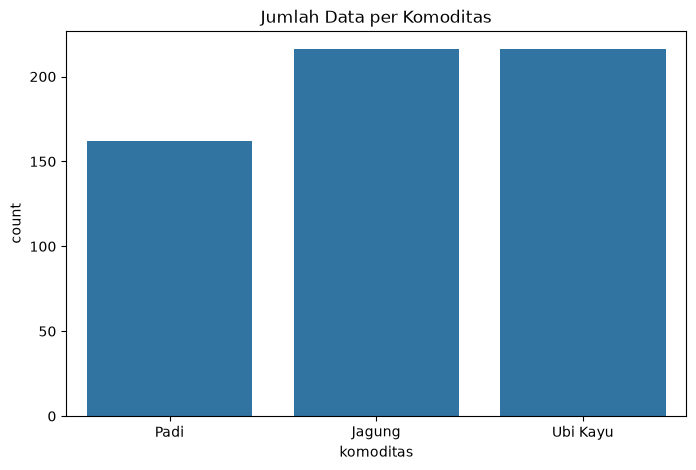

In [6]:
#distribusi komoditas

plt.figure(figsize=(8,5))

sns.countplot(
    data=crop,
    x="komoditas"
)

plt.title("Jumlah Data per Komoditas")
plt.show()

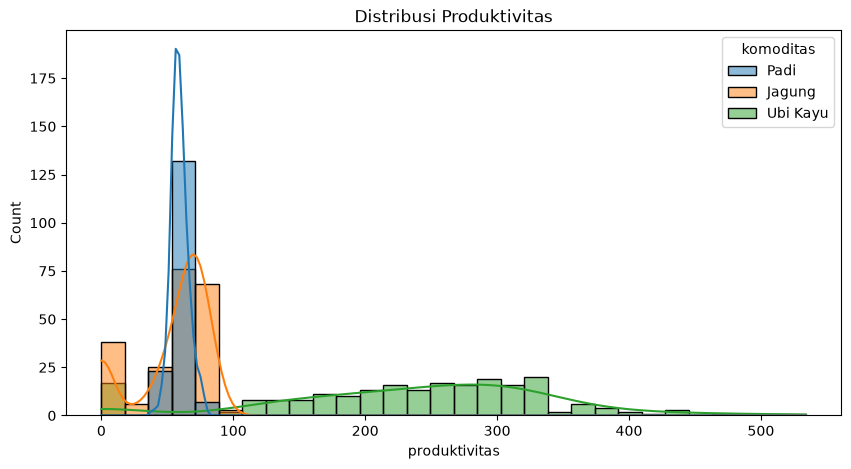

In [8]:
#distribusi produktivitas
plt.figure(figsize=(10,5))

sns.histplot(
    data=crop,
    x="produktivitas",
    hue="komoditas",
    kde=True,
    bins=30
)

plt.title(
    "Distribusi Produktivitas"
)

plt.show()

komoditas
Ubi Kayu    237.511481
Padi         59.232284
Jagung       54.497176
Name: produktivitas, dtype: float64


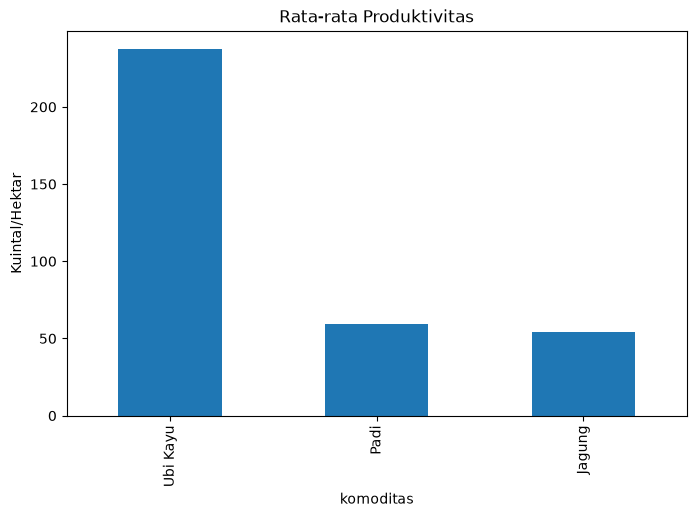

In [10]:
#produktivitas rata-rata per komoditas
avg_prod = (
    crop.groupby("komoditas")
    ["produktivitas"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_prod)

avg_prod.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Rata-rata Produktivitas"
)

plt.ylabel(
    "Kuintal/Hektar"
)

plt.show()

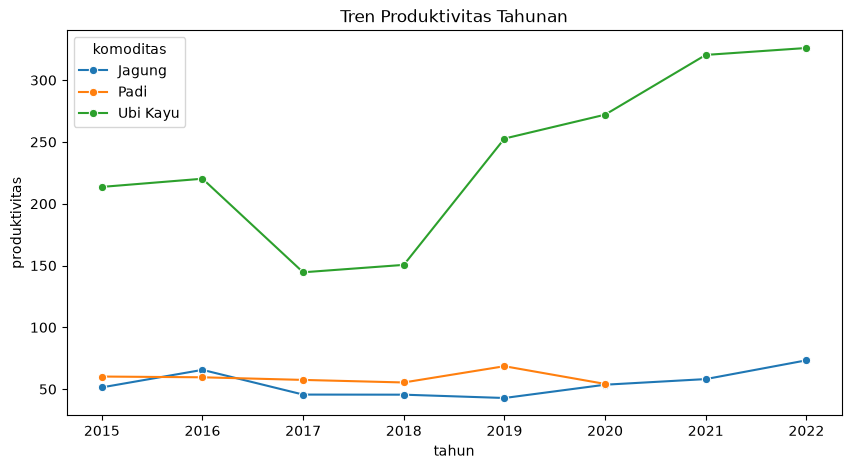

In [11]:
#tren produktivitas per tahun
yearly = (
    crop.groupby(
        ["tahun","komoditas"]
    )["produktivitas"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly,
    x="tahun",
    y="produktivitas",
    hue="komoditas",
    marker="o"
)

plt.title(
    "Tren Produktivitas Tahunan"
)

plt.show()

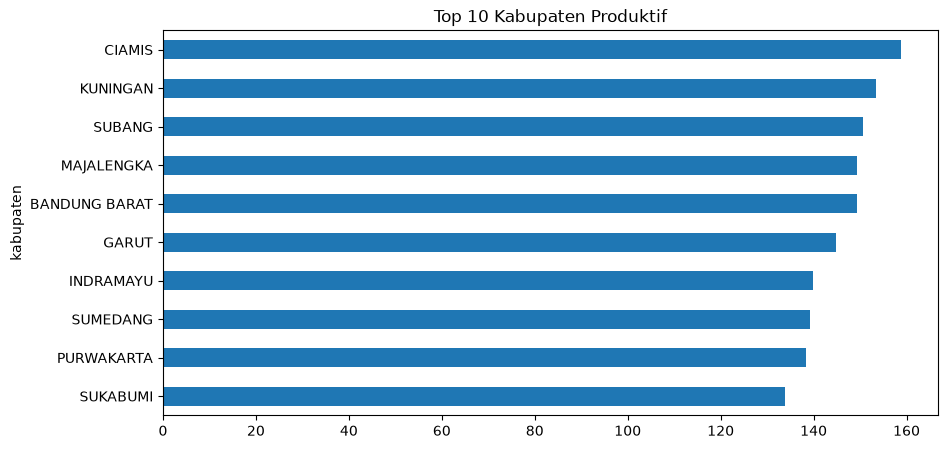

In [12]:
#top 10 kabupaten produktivitas tertinggi
top = (
    crop.groupby("kabupaten")
    ["produktivitas"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Kabupaten Produktif"
)

plt.show()

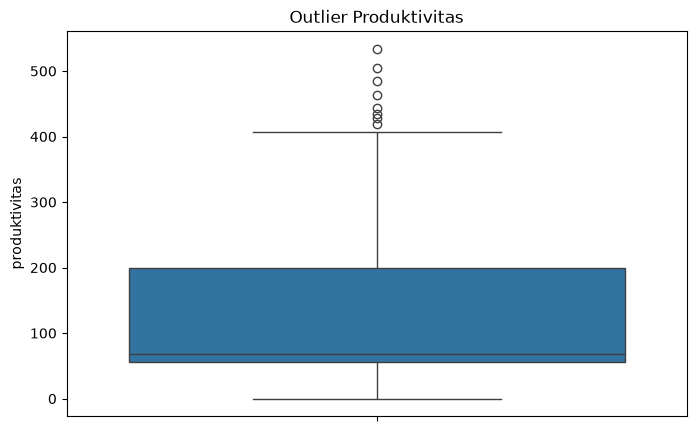

In [ ]:
#boxplot outlier produktivitas
plt.figure(figsize=(8,5))

sns.boxplot(
    y=crop["produktivitas"]
)

plt.title(
    "Outlier Produktivitas"
)

plt.show()

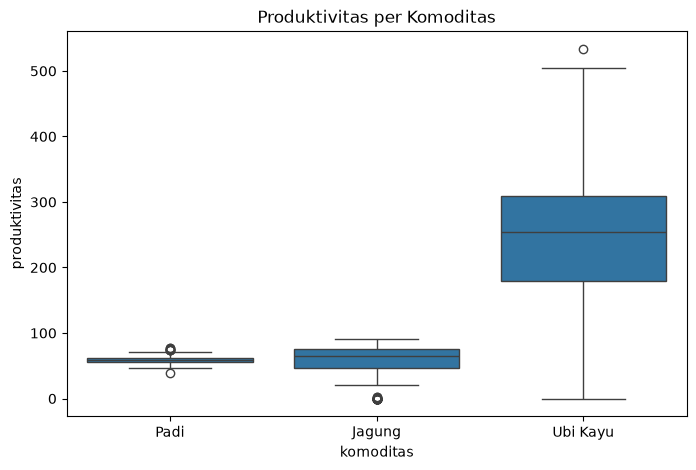

In [9]:
#boxplot outlier
plt.figure(figsize=(8,5))

sns.boxplot(
    data=crop,
    x="komoditas",
    y="produktivitas"
)

plt.title(
    "Produktivitas per Komoditas"
)

plt.show()

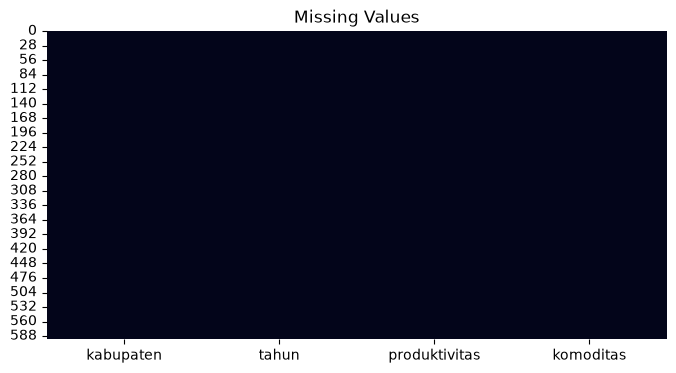

In [14]:
#heatmap missing value
plt.figure(figsize=(8,4))

sns.heatmap(
    crop.isnull(),
    cbar=False
)

plt.title(
    "Missing Values"
)

plt.show()